Why interpolation is required in fixed income

Linear interpolation

Cubic spline interpolation

Nelson–Siegel parametric curve fitting

Forward rates

Advantages and disadvantages of each approach

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit

In [2]:
from pathlib import Path

ROOT = Path.cwd().parent

In [3]:
zero_curve = pd.read_csv(ROOT / "data/zero_curve.csv")

zero_curve.head()

,Unnamed: 0,Years,Discount Factor,Spot Rate
0,0,0.25,0.990505,3.890000
1,1,0.50,0.980439,4.030000
2,2,1.00,0.960430,4.120000
3,3,1.50,0.939646,4.237461
4,4,2.00,0.919069,4.310007


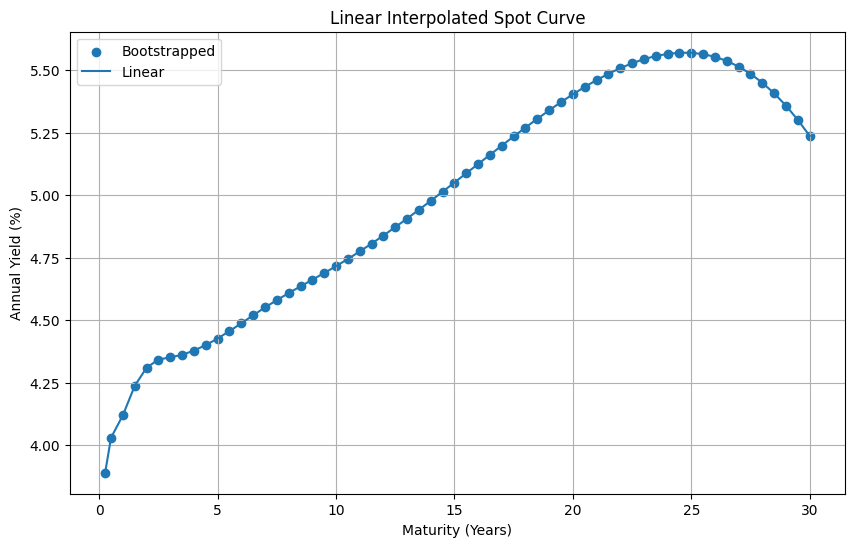

In [4]:
# Linear interpolation
linear = interp1d(
    zero_curve["Years"],
    zero_curve["Spot Rate"],
    kind="linear",
    fill_value="extrapolate"
)

grid = np.linspace(
    0.25,
    30,
    500
)

linear_rates = linear(grid)

plt.figure(figsize=(10,6))

plt.scatter(
    zero_curve["Years"],
    zero_curve["Spot Rate"],
    label="Bootstrapped"
)

plt.plot(
    grid,
    linear_rates,
    label="Linear"
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Annual Yield (%)")
plt.title("Linear Interpolated Spot Curve")

plt.legend()
plt.grid()

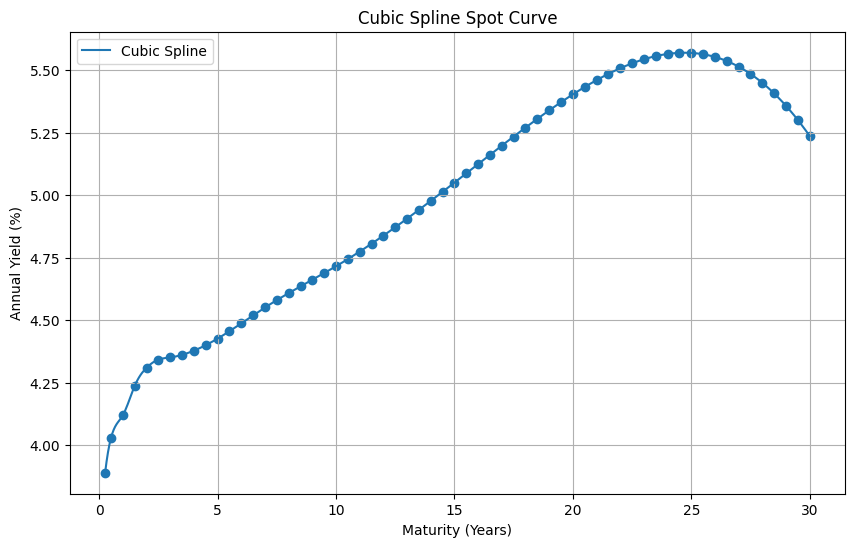

In [5]:
# Cubic Spline
spline = CubicSpline(
    zero_curve["Years"],
    zero_curve["Spot Rate"] 
)

spline_rates = spline(grid)

plt.figure(figsize=(10,6))

plt.scatter(
    zero_curve["Years"],
    zero_curve["Spot Rate"] 
)

plt.plot(
    grid,
    spline_rates,
    label="Cubic Spline"
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Annual Yield (%)")
plt.title("Cubic Spline Spot Curve")

plt.legend()
plt.grid()

In [6]:
# Nelson-Siegel Model
def nelson_siegel(t, b0, b1, b2, tau):
    x = t / tau
    A = (1 - np.exp(-x)) / x
    B = A - np.exp(-x)
    return b0 + b1 * A + b2 * B

# Curve fit
params, _ = curve_fit(
    nelson_siegel,
    zero_curve["Years"],
    zero_curve["Spot Rate"],
    p0=[4,-1,1,2]
)

ns_rates = nelson_siegel(grid, *params)

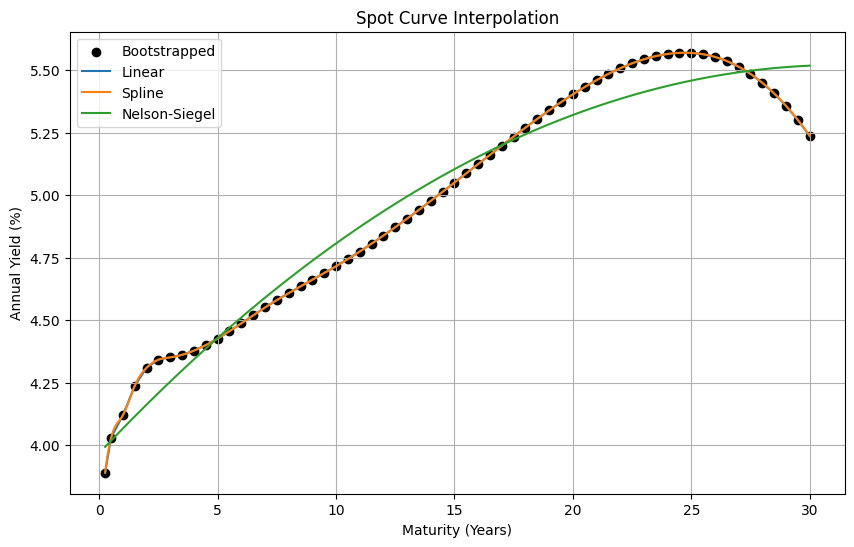

In [7]:
plt.figure(figsize=(10,6))

plt.scatter(
    zero_curve["Years"],
    zero_curve["Spot Rate"],
    color="black",
    label="Bootstrapped"
)

plt.plot(
    grid,
    linear_rates,
    label="Linear"
)

plt.plot(
    grid,
    spline_rates,
    label="Spline"
)

plt.plot(
    grid,
    ns_rates,
    label="Nelson-Siegel"
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Annual Yield (%)")
plt.title("Spot Curve Interpolation")

plt.legend()
plt.grid()

In [8]:
# Error analysis
from sklearn.metrics import root_mean_squared_error

rmse_linear = root_mean_squared_error(zero_curve["Spot Rate"], linear(zero_curve["Years"]))
rmse_spline = root_mean_squared_error(zero_curve["Spot Rate"], spline(zero_curve["Years"]))
rmse_ns = root_mean_squared_error(zero_curve["Spot Rate"], nelson_siegel(zero_curve["Years"], *params))

print(rmse_linear)
print(rmse_spline)
print(rmse_ns)

0.0
1.1371959368213422e-16
0.09358933350521234


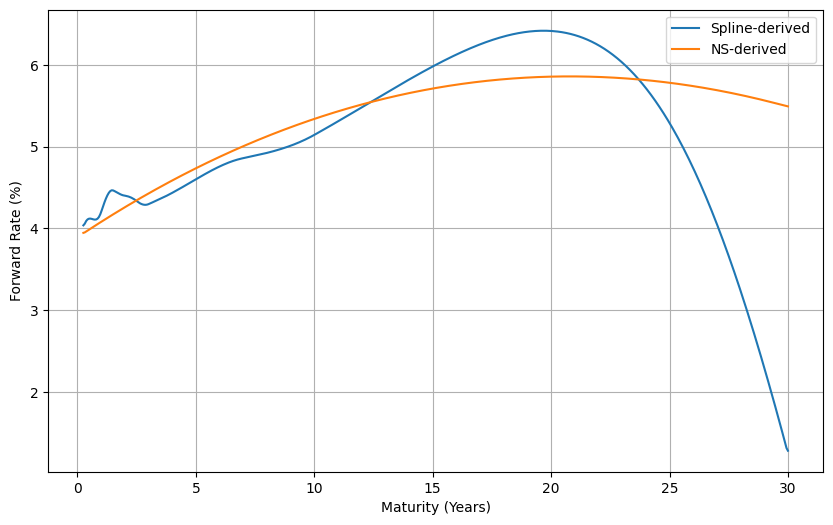

In [9]:
# Forward rates
def forward(rates, grid = grid):

    spot = rates / 100

    df = 1 / (1 + spot) ** grid

    return -np.gradient(np.log(df), grid)

plt.figure(figsize=(10,6))

plt.plot(
    grid,
    forward(spline_rates) * 100, 
    label = "Spline-derived"
)

plt.plot(
    grid,
    forward(ns_rates) * 100, 
    label = "NS-derived"
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Forward Rate (%)")

plt.legend()
plt.grid()


In [10]:
continuous_curve = pd.DataFrame({
    "Years": grid,
    "Spot": spline_rates
})

continuous_curve.to_csv(ROOT / "data/continuous_zero_curve.csv", index=False)